# ANÁLISE DE PREÇOS DE PRODUTOS AGRÍCOLAS

### HARIEL
### IGOR
### JAYCE

Fonte da base de dados: dados da conab referente a diversos produtos: https://www.kaggle.com/datasets/jeffersonvalandro/conab-valor-dos-produtos-no-brasil?select=relatorio_preco_medio_mensal_2023.csv

**A base de dados apresenta preços médios mensais de diversos produtos agrícolas coletados pela Companhia Nacional de Abastecimento (Conab). Não há uma uniformidade nos dados, não existem dados de preços em todos os estados para todos os produtos. Os preços são apresentados em três níveis de comercialização: preços ao produtor, preços no atacado e preços no varejo; também não há uniformidade nisso, a maioria dos produtos tem preços em apenas um dos níveis.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#carregando o dataframe

df = pd.read_csv('dados_conab/relatorio_preco_medio_mensal_2023.csv')


In [4]:
#pedindo as primeiras 20 linhas

df.head(20)

,Produto/Unidade,Nível de Comercialização,U.F.,01/2023,02/2023,03/2023,04/2023,05/2023,06/2023,07/2023,08/2023,09/2023,10/2023,11/2023,12/2023
0,ABACATE (kg),ATACADO,RR,"6,83","6,67","6,83","7,00","7,00","6,00","6,00","6,60","7,00","7,00","7,00","7,00"
1,ABACAXI HAVAÍ (kg),PRODUTOR,PR,"1,85","2,31","2,30","2,30","2,30",NaN,NaN,NaN,NaN,NaN,"2,60","2,60"
2,ABACAXI (kg),ATACADO,RR,"2,59","2,65","2,79","6,00","8,00","4,50","4,50","4,95","5,00","7,50","7,00","7,50"
3,ABACAXI PÉROLA (6.50 kg),PRODUTOR,DF,"21,80","20,14","23,45","26,65","34,82","36,87","25,47","27,36","28,48","31,92","25,05","25,75"
4,ABACAXI PÉROLA (kg),NaN,AM,"3,81","3,75","3,75","3,90","4,00","4,25","4,02","3,94","4,27","4,25","4,51","4,23"
5,NaN,NaN,AP,"3,20","3,40","3,40","3,55","3,72","3,81","3,63","3,43","3,17",NaN,"3,42","3,25"
6,NaN,NaN,ES,"2,30","2,56","3,04","3,35","3,36","3,27","3,13","3,11","3,10","3,03","3,00","3,06"
7,NaN,NaN,RR,"2,17","2,13","2,24","3,62","3,93","4,14","3,90","5,74","6,50","6,50","6,70","6,52"
8,ABACAXI PÉROLA (t),NaN,BA,NaN,NaN,NaN,NaN,"2.000,00","1.977,27","2.050,00","2.204,35","2.295,24","2.325,00","2.300,00",NaN
9,NaN,NaN,SP,"1.587,50","1.744,44","1.862,50",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

Produto/Unidade             1478
Nível de Comercialização    1720
U.F.                           5
01/2023                      128
02/2023                      127
03/2023                      155
04/2023                      155
05/2023                      145
06/2023                      150
07/2023                      177
08/2023                      248
09/2023                      264
10/2023                      323
11/2023                      426
12/2023                      450
dtype: int64

**Acima vemos as primeiras 20 linhas da base de dados, as colunas Produto/Unidade e Nível de Comercialização apresentam muitos valores nulos. O motivo é que o nome de produto é apresentado na primeira linha e vale para as próximas, até que apareça outro valor, o mesmo vale para os níveis de comercialização.**

In [6]:
#pedindo as últimas 20 linhas

df.tail(20)

,Produto/Unidade,Nível de Comercialização,U.F.,01/2023,02/2023,03/2023,04/2023,05/2023,06/2023,07/2023,08/2023,09/2023,10/2023,11/2023,12/2023
2009,NaN,NaN,SC,NaN,"1,40","1,39","1,38","1,38",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010,UVA INDÚSTRIA NIÁGARA BRANCA (kg),NaN,MG,NaN,"6,36",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011,UVA INDÚSTRIA NIÁGARA (kg),NaN,SP,"4,54","4,15",NaN,NaN,"5,22","5,07","5,56","5,58","5,98","6,32","6,94","6,58"
2012,UVA MOSCATO (kg),NaN,RS,"2,13","2,13","2,13","2,13","1,89","1,89","1,89","1,89","1,89","1,89","1,89","1,89"
2013,UVA NIÁGARA (kg),NaN,RS,"1,58","1,58","1,58","1,58","1,40","1,40","1,40","1,40","1,40","1,40","1,40","1,40"
2014,VACA GORDA (@),NaN,TO,"244,46","221,85","207,12","209,71","192,51","174,68","185,56",NaN,NaN,NaN,NaN,NaN
2015,VACA GORDA (15 kg),NaN,DF,"277,75","267,00","240,65","225,50","223,00","197,09","188,33",NaN,NaN,NaN,NaN,NaN
2016,NaN,NaN,GO,"252,94","240,07","228,99","232,50","203,34","190,54","203,67",NaN,NaN,NaN,NaN,NaN
2017,NaN,NaN,MG,"238,85","243,21","237,23","241,77","216,44","195,29","195,68",NaN,NaN,NaN,NaN,NaN
2018,NaN,NaN,MS,"237,25","235,61","240,22","245,75","221,48","214,14","226,50",NaN,NaN,NaN,NaN,NaN


**Nas últimas linhas vemos que as três últimas foram usadas para informações sobre a base e mais duas linhas antes disso foram deixadas em branco. Foi necessário a eliminação das últimas 5 linhas para que não interfira na análise.**

In [7]:
#eliminar as últimas 5 linhas, que não tem dados.

df = df.iloc[:-5]
df.tail(20)

,Produto/Unidade,Nível de Comercialização,U.F.,01/2023,02/2023,03/2023,04/2023,05/2023,06/2023,07/2023,08/2023,09/2023,10/2023,11/2023,12/2023
2004,NaN,NaN,PE,"5,00","4,83","5,42","4,94","4,49","3,90","4,13","4,40","4,69","5,00","5,97","6,38"
2005,UVA DE MESA NIÁGARA (kg),NaN,PR,"4,32","4,39","4,99","6,20","6,33","6,42","7,21","7,22","7,19","7,29","5,77","5,35"
2006,UVA GAMAY SAINT ROMAIN (kg),NaN,RS,"1,89","1,89","1,89","1,89","1,68","1,68","1,68","1,68","1,68","1,68","1,68","1,68"
2007,UVA INDÚSTRIA BORDÔ (kg),NaN,MG,NaN,"5,07",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008,UVA INDÚSTRIA ISABEL (kg),NaN,RS,"1,45","1,58","1,58","1,58","1,40","1,40","1,40","1,40","1,40","1,40","1,40","1,40"
2009,NaN,NaN,SC,NaN,"1,40","1,39","1,38","1,38",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010,UVA INDÚSTRIA NIÁGARA BRANCA (kg),NaN,MG,NaN,"6,36",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011,UVA INDÚSTRIA NIÁGARA (kg),NaN,SP,"4,54","4,15",NaN,NaN,"5,22","5,07","5,56","5,58","5,98","6,32","6,94","6,58"
2012,UVA MOSCATO (kg),NaN,RS,"2,13","2,13","2,13","2,13","1,89","1,89","1,89","1,89","1,89","1,89","1,89","1,89"
2013,UVA NIÁGARA (kg),NaN,RS,"1,58","1,58","1,58","1,58","1,40","1,40","1,40","1,40","1,40","1,40","1,40","1,40"


**Para solucionar os valores nulos nas duas primeiras colunas foi necessário um comando de preenchimento.**
**As linhas em branco foram preenchidas com o mesmo valor da primeira linha preenchida acima.**
**As células sem valores nas colunas de preços demonstram a sazonalidade da produção e comercialização de determinados produtos agrícolas e não foram transformadas ou eliminadas.**

In [8]:
#preencher linhas em branco com o mesmo valor da primeira linha preenchida acima nas colunas Produto/Unidade e Nível de Comercialização

df['Produto/Unidade'] = df['Produto/Unidade'].ffill()
df['Nível de Comercialização'] = df['Nível de Comercialização'].ffill()

df.isnull().sum()

Produto/Unidade               0
Nível de Comercialização      0
U.F.                          0
01/2023                     123
02/2023                     122
03/2023                     150
04/2023                     150
05/2023                     140
06/2023                     145
07/2023                     172
08/2023                     243
09/2023                     259
10/2023                     318
11/2023                     421
12/2023                     445
dtype: int64

In [9]:
#pedindo 20 linhas aleatórias de exemplo dos dados

df.sample(20)

,Produto/Unidade,Nível de Comercialização,U.F.,01/2023,02/2023,03/2023,04/2023,05/2023,06/2023,07/2023,08/2023,09/2023,10/2023,11/2023,12/2023
468,CARNE BOVINA CHARQUE PA CRAY-O-VAC (500 g),VAREJO,SP,"20,38","19,77","19,90","19,33","20,05","19,22","19,63","19,03","19,60","19,30",NaN,NaN
628,CARNE SUÍNA RESFRIADO PERNIL COM OSSO (kg),VAREJO,RS,"19,52","20,18","19,11","19,49","18,23","16,33","16,04","17,29","17,21","18,36","17,81","18,07"
282,BATATA-DOCE (kg),PRODUTOR,MT,"1,83","1,89","1,90","1,95","2,05","1,98","1,81","1,99","2,00","1,93","1,93","2,26"
684,CEBOLA (kg),VAREJO,ES,"8,01","7,07","4,94","5,81","5,96","6,50","5,66","5,60","4,99","5,27","7,90","7,43"
106,ALHO COMUM (10 kg),PRODUTOR,GO,"93,75","71,00","65,00","67,50",NaN,"70,00","76,25","81,96","88,57","81,25","80,00","80,00"
552,CARNE DE FRANGO CONGELADO (kg),VAREJO,MG,"12,38","11,89","13,79","13,64","13,73","13,70","8,17","10,42","13,32","13,03","13,02","13,73"
1075,FLOCOS DE MILHO ENRIQUECIDO (15 kg),ATACADO,PB,"53,60","53,40","53,20","53,95","51,39","48,50","50,93",NaN,NaN,NaN,NaN,NaN
1385,LEITE DE VACA LONGA VIDA INTEGRAL (l),VAREJO,CE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"4,34","4,21"
823,FARINHA DE MANDIOCA MÉDIA TIPO 1 SECA (kg),VAREJO,TO,"6,57","6,98","7,46","7,74","7,73","7,27","7,07","7,27","7,31","6,75","6,76","6,75"
593,CARNE SUÍNA CONGELADA CARCAÇA (kg),ATACADO,MG,"11,12","11,69","11,31","9,72","10,34","9,67","10,33","9,72","10,23","9,90","10,42","12,11"


**A coluna Produto/Unidade não tem a unidade padronizada, o mesmo produto pode estar em quilos, toneladas, etc., por isso foi feita a separação em duas colunas.**

In [10]:
#separa produto e unidade de medida e cria duas colunas. Pois, tem o mesmo produto em KG, toneladam, unidade, dúzia, litro... misturados na coluna Produto/Unidade
extracted = df['Produto/Unidade'].str.extract(r'^(.*?)\s*\(([^)]+)\)\s*$')
df['produto_nome'] = extracted[0].str.strip()
df['unidade'] = extracted[1].str.strip()
df.head(20)

,Produto/Unidade,Nível de Comercialização,U.F.,01/2023,02/2023,03/2023,04/2023,05/2023,06/2023,07/2023,08/2023,09/2023,10/2023,11/2023,12/2023,produto_nome,unidade
0,ABACATE (kg),ATACADO,RR,"6,83","6,67","6,83","7,00","7,00","6,00","6,00","6,60","7,00","7,00","7,00","7,00",ABACATE,kg
1,ABACAXI HAVAÍ (kg),PRODUTOR,PR,"1,85","2,31","2,30","2,30","2,30",NaN,NaN,NaN,NaN,NaN,"2,60","2,60",ABACAXI HAVAÍ,kg
2,ABACAXI (kg),ATACADO,RR,"2,59","2,65","2,79","6,00","8,00","4,50","4,50","4,95","5,00","7,50","7,00","7,50",ABACAXI,kg
3,ABACAXI PÉROLA (6.50 kg),PRODUTOR,DF,"21,80","20,14","23,45","26,65","34,82","36,87","25,47","27,36","28,48","31,92","25,05","25,75",ABACAXI PÉROLA,6.50 kg
4,ABACAXI PÉROLA (kg),PRODUTOR,AM,"3,81","3,75","3,75","3,90","4,00","4,25","4,02","3,94","4,27","4,25","4,51","4,23",ABACAXI PÉROLA,kg
5,ABACAXI PÉROLA (kg),PRODUTOR,AP,"3,20","3,40","3,40","3,55","3,72","3,81","3,63","3,43","3,17",NaN,"3,42","3,25",ABACAXI PÉROLA,kg
6,ABACAXI PÉROLA (kg),PRODUTOR,ES,"2,30","2,56","3,04","3,35","3,36","3,27","3,13","3,11","3,10","3,03","3,00","3,06",ABACAXI PÉROLA,kg
7,ABACAXI PÉROLA (kg),PRODUTOR,RR,"2,17","2,13","2,24","3,62","3,93","4,14","3,90","5,74","6,50","6,50","6,70","6,52",ABACAXI PÉROLA,kg
8,ABACAXI PÉROLA (t),PRODUTOR,BA,NaN,NaN,NaN,NaN,"2.000,00","1.977,27","2.050,00","2.204,35","2.295,24","2.325,00","2.300,00",NaN,ABACAXI PÉROLA,t
9,ABACAXI PÉROLA (t),PRODUTOR,SP,"1.587,50","1.744,44","1.862,50",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ABACAXI PÉROLA,t


**Os preços não estão em formato numérico, foi necessário um comando para conversão.**

In [11]:
#converte os preços de texto para número
meses = ['01/2023','02/2023','03/2023','04/2023','05/2023','06/2023',
         '07/2023','08/2023','09/2023','10/2023','11/2023','12/2023']

for col in meses:
    df[col] = (df[col].astype(str)
                       .str.replace('.', '', regex=False)
                       .str.replace(',', '.', regex=False)
                       .replace('nan', np.nan)
                       .astype(float))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2024 entries, 0 to 2023
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Produto/Unidade           2024 non-null   object 
 1   Nível de Comercialização  2024 non-null   object 
 2   U.F.                      2024 non-null   object 
 3   01/2023                   1901 non-null   float64
 4   02/2023                   1902 non-null   float64
 5   03/2023                   1874 non-null   float64
 6   04/2023                   1874 non-null   float64
 7   05/2023                   1884 non-null   float64
 8   06/2023                   1879 non-null   float64
 9   07/2023                   1852 non-null   float64
 10  08/2023                   1781 non-null   float64
 11  09/2023                   1765 non-null   float64
 12  10/2023                   1706 non-null   float64
 13  11/2023                   1603 non-null   float64
 14  12/2023 

**Os preços são apresentados em 12 colunas referentes aos meses, isso pode dificultar a análise. Então as 12 colunas foram transformadas em duas, uma contendo o mês e outra contendo o preço.**

In [12]:
#transforma as 12 colunas de mês em 2 colunas: mes_ano e preco_medio(daquele mês)

df_novo = df.melt(
    id_vars=['produto_nome', 'unidade', 'Nível de Comercialização', 'U.F.'],
    value_vars=meses,
    var_name='mes_ano',
    value_name='preco_medio'
)
df_novo.head(20)


,produto_nome,unidade,Nível de Comercialização,U.F.,mes_ano,preco_medio
0,ABACATE,kg,ATACADO,RR,01/2023,6.83
1,ABACAXI HAVAÍ,kg,PRODUTOR,PR,01/2023,1.85
2,ABACAXI,kg,ATACADO,RR,01/2023,2.59
3,ABACAXI PÉROLA,6.50 kg,PRODUTOR,DF,01/2023,21.80
4,ABACAXI PÉROLA,kg,PRODUTOR,AM,01/2023,3.81
5,ABACAXI PÉROLA,kg,PRODUTOR,AP,01/2023,3.20
6,ABACAXI PÉROLA,kg,PRODUTOR,ES,01/2023,2.30
7,ABACAXI PÉROLA,kg,PRODUTOR,RR,01/2023,2.17
8,ABACAXI PÉROLA,t,PRODUTOR,BA,01/2023,NaN
9,ABACAXI PÉROLA,t,PRODUTOR,SP,01/2023,1587.50


**Para ampliar as possibilidades de análise foi criada uma nova colunas, contendo a região geográfica à qual o estado pertence.**

In [14]:
regiao_map = {
    'AC':'Norte','AP':'Norte','AM':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste',
    'PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MT':'Centro-Oeste','MS':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}
df_regiao = pd.DataFrame(list(regiao_map.items()), columns=['U.F.', 'regiao'])

linhas_antes = len(df_novo)
df_novo = df_novo.merge(df_regiao, on='U.F.', how='left')
print(linhas_antes, len(df_novo))  # confere se bateu — sem duplicar linha

24288 24288


In [15]:
df_novo.head(20)

,produto_nome,unidade,Nível de Comercialização,U.F.,mes_ano,preco_medio,regiao_x,regiao_y
0,ABACATE,kg,ATACADO,RR,01/2023,6.83,Norte,Norte
1,ABACAXI HAVAÍ,kg,PRODUTOR,PR,01/2023,1.85,Sul,Sul
2,ABACAXI,kg,ATACADO,RR,01/2023,2.59,Norte,Norte
3,ABACAXI PÉROLA,6.50 kg,PRODUTOR,DF,01/2023,21.80,Centro-Oeste,Centro-Oeste
4,ABACAXI PÉROLA,kg,PRODUTOR,AM,01/2023,3.81,Norte,Norte
5,ABACAXI PÉROLA,kg,PRODUTOR,AP,01/2023,3.20,Norte,Norte
6,ABACAXI PÉROLA,kg,PRODUTOR,ES,01/2023,2.30,Sudeste,Sudeste
7,ABACAXI PÉROLA,kg,PRODUTOR,RR,01/2023,2.17,Norte,Norte
8,ABACAXI PÉROLA,t,PRODUTOR,BA,01/2023,NaN,Nordeste,Nordeste
9,ABACAXI PÉROLA,t,PRODUTOR,SP,01/2023,1587.50,Sudeste,Sudeste


## Análise 1: Qual produto apresentou o maior aumento percentual entre janeiro e dezembro de 2023?

Produto com maior aumento: FARINHA DE TRIGO ESPECIAL (kg)
Aumento de 7097.28% (de R$6.31 para R$454.51)


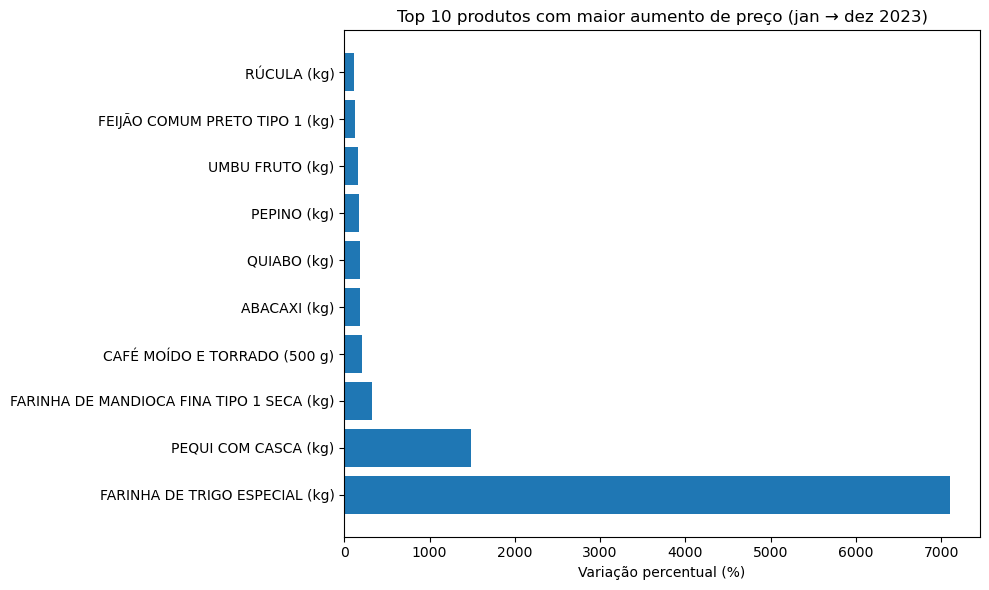

In [16]:
# Filtrar apenas janeiro e dezembro
df_jan = df_novo[df_novo['mes_ano'] == '01/2023']
df_dez = df_novo[df_novo['mes_ano'] == '12/2023']

# Agrupar por produto e unidade para ter o preço médio nacional em cada mês
preco_jan = df_jan.groupby(['produto_nome', 'unidade'])['preco_medio'].mean().reset_index(name='preco_jan')
preco_dez = df_dez.groupby(['produto_nome', 'unidade'])['preco_medio'].mean().reset_index(name='preco_dez')

# Juntar as duas tabelas
variacao = pd.merge(preco_jan, preco_dez, on=['produto_nome', 'unidade'])

# Calcular a variação percentual
variacao['variacao_pct'] = (variacao['preco_dez'] - variacao['preco_jan']) / variacao['preco_jan'] * 100

# Produto com maior aumento
top_produto = variacao.loc[variacao['variacao_pct'].idxmax()]
print(f"Produto com maior aumento: {top_produto['produto_nome']} ({top_produto['unidade']})")
print(f"Aumento de {top_produto['variacao_pct']:.2f}% (de R${top_produto['preco_jan']:.2f} para R${top_produto['preco_dez']:.2f})")

# Visualizar os 10 maiores aumentos
top10 = variacao.nlargest(10, 'variacao_pct')
plt.figure(figsize=(10,6))
plt.barh(top10['produto_nome'] + ' (' + top10['unidade'] + ')', top10['variacao_pct'])
plt.xlabel('Variação percentual (%)')
plt.title('Top 10 produtos com maior aumento de preço (jan → dez 2023)')
plt.tight_layout()
plt.show()

**Aqui podemos observar um valor bem discrepante para a Farinha de trigo especial.**

In [17]:
df_novo[
    (df_novo['produto_nome'] == 'FARINHA DE TRIGO ESPECIAL') & (df_novo['unidade'] == 'kg')
].sort_values('preco_medio', ascending=False)

,produto_nome,unidade,Nível de Comercialização,U.F.,mes_ano,preco_medio,regiao_x,regiao_y
23150,FARINHA DE TRIGO ESPECIAL,kg,ATACADO,SP,12/2023,4948.00,Sudeste,Sudeste
13031,FARINHA DE TRIGO ESPECIAL,kg,VAREJO,CE,07/2023,10.15,Nordeste,Nordeste
8983,FARINHA DE TRIGO ESPECIAL,kg,VAREJO,CE,05/2023,9.91,Nordeste,Nordeste
11007,FARINHA DE TRIGO ESPECIAL,kg,VAREJO,CE,06/2023,9.85,Nordeste,Nordeste
2911,FARINHA DE TRIGO ESPECIAL,kg,VAREJO,CE,02/2023,9.67,Nordeste,Nordeste
...,...,...,...,...,...,...,...,...
13030,FARINHA DE TRIGO ESPECIAL,kg,ATACADO,SP,07/2023,NaN,Sudeste,Sudeste
15054,FARINHA DE TRIGO ESPECIAL,kg,ATACADO,SP,08/2023,NaN,Sudeste,Sudeste
17078,FARINHA DE TRIGO ESPECIAL,kg,ATACADO,SP,09/2023,NaN,Sudeste,Sudeste
19102,FARINHA DE TRIGO ESPECIAL,kg,ATACADO,SP,10/2023,NaN,Sudeste,Sudeste


In [ ]:
**O valor mais alto vem de um preço de atacado que provavelmente está com a unidade errada, deveria ser tonelada e está em quilograma. Para melhorar a análise, vamos separar os preços por nível de comercialização.**

Produto com maior aumento: PEQUI COM CASCA (kg)
Aumento de 1487.83% (de R$0.63 para R$10.00)


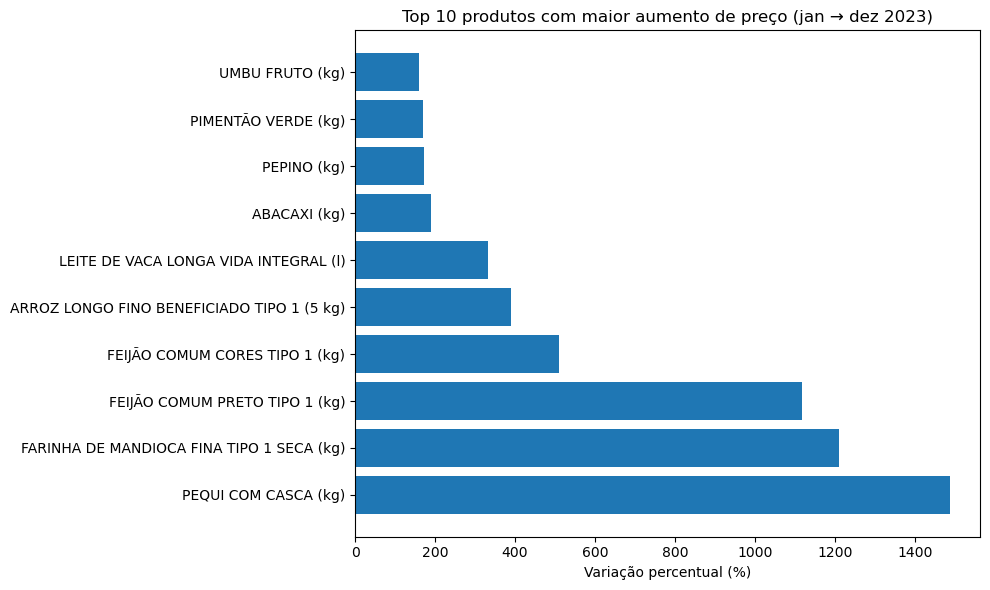

In [18]:
# Filtrar apenas janeiro e dezembro
df_jan = df_novo[df_novo['mes_ano'] == '01/2023']
df_dez = df_novo[df_novo['mes_ano'] == '12/2023']

# Agrupar por produto e unidade para ter o preço médio nacional em cada mês
preco_jan = df_jan.groupby(['produto_nome', 'unidade', 'Nível de Comercialização'])['preco_medio'].mean().reset_index(name='preco_jan')
preco_dez = df_dez.groupby(['produto_nome', 'unidade', 'Nível de Comercialização'])['preco_medio'].mean().reset_index(name='preco_dez')

# Juntar as duas tabelas
variacao = pd.merge(preco_jan, preco_dez, on=['produto_nome', 'unidade', 'Nível de Comercialização'])

# Calcular a variação percentual
variacao['variacao_pct'] = (variacao['preco_dez'] - variacao['preco_jan']) / variacao['preco_jan'] * 100

# Produto com maior aumento
top_produto = variacao.loc[variacao['variacao_pct'].idxmax()]
print(f"Produto com maior aumento: {top_produto['produto_nome']} ({top_produto['unidade']})")
print(f"Aumento de {top_produto['variacao_pct']:.2f}% (de R${top_produto['preco_jan']:.2f} para R${top_produto['preco_dez']:.2f})")

# Visualizar os 10 maiores aumentos
top10 = variacao.nlargest(10, 'variacao_pct')
plt.figure(figsize=(10,6))
plt.barh(top10['produto_nome'] + ' (' + top10['unidade'] + ')', top10['variacao_pct'])
plt.xlabel('Variação percentual (%)')
plt.title('Top 10 produtos com maior aumento de preço (jan → dez 2023)')
plt.tight_layout()
plt.show()

**Vamos analisar qual a origem da grande variação do pequi.**

In [19]:
df_novo[
    (df_novo['produto_nome'] == 'PEQUI COM CASCA') & (df_novo['unidade'] == 'kg')
].sort_values('preco_medio', ascending=False)

,produto_nome,unidade,Nível de Comercialização,U.F.,mes_ano,preco_medio,regiao_x,regiao_y
24012,PEQUI COM CASCA,kg,PRODUTOR,CE,12/2023,20.42,Nordeste,Nordeste
24011,PEQUI COM CASCA,kg,PRODUTOR,BA,12/2023,8.03,Nordeste,Nordeste
7820,PEQUI COM CASCA,kg,PRODUTOR,CE,04/2023,2.88,Nordeste,Nordeste
5796,PEQUI COM CASCA,kg,PRODUTOR,CE,03/2023,1.75,Nordeste,Nordeste
3772,PEQUI COM CASCA,kg,PRODUTOR,CE,02/2023,1.74,Nordeste,Nordeste
21989,PEQUI COM CASCA,kg,PRODUTOR,GO,11/2023,1.56,Centro-Oeste,Centro-Oeste
24013,PEQUI COM CASCA,kg,PRODUTOR,GO,12/2023,1.56,Centro-Oeste,Centro-Oeste
17942,PEQUI COM CASCA,kg,PRODUTOR,MG,09/2023,1.30,Sudeste,Sudeste
15918,PEQUI COM CASCA,kg,PRODUTOR,MG,08/2023,1.04,Sudeste,Sudeste
3774,PEQUI COM CASCA,kg,PRODUTOR,MG,02/2023,0.83,Sudeste,Sudeste


**Existe uma grande variação por estado, vamos refazer a análise separando também por estados.**

Produto com maior aumento: MANGABA FRUTO (kg)
Aumento de 376.19% (de R$1.05 para R$5.00)


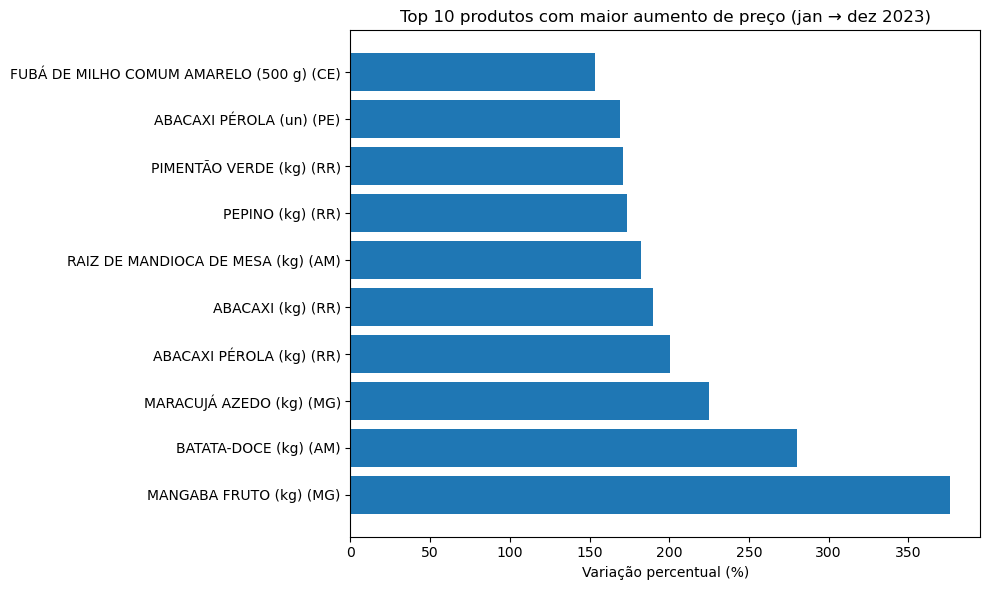

In [20]:
# Filtrar apenas janeiro e dezembro
df_jan = df_novo[df_novo['mes_ano'] == '01/2023']
df_dez = df_novo[df_novo['mes_ano'] == '12/2023']

# Agrupar por produto e unidade para ter o preço médio nacional em cada mês
preco_jan = df_jan.groupby(['produto_nome', 'unidade', 'Nível de Comercialização', 'U.F.'])['preco_medio'].mean().reset_index(name='preco_jan')
preco_dez = df_dez.groupby(['produto_nome', 'unidade', 'Nível de Comercialização', 'U.F.'])['preco_medio'].mean().reset_index(name='preco_dez')

# Juntar as duas tabelas
variacao = pd.merge(preco_jan, preco_dez, on=['produto_nome', 'unidade', 'Nível de Comercialização', 'U.F.'])

# Calcular a variação percentual
variacao['variacao_pct'] = (variacao['preco_dez'] - variacao['preco_jan']) / variacao['preco_jan'] * 100

# Produto com maior aumento
top_produto = variacao.loc[variacao['variacao_pct'].idxmax()]
print(f"Produto com maior aumento: {top_produto['produto_nome']} ({top_produto['unidade']})")
print(f"Aumento de {top_produto['variacao_pct']:.2f}% (de R${top_produto['preco_jan']:.2f} para R${top_produto['preco_dez']:.2f})")

# Visualizar os 10 maiores aumentos
top10 = variacao.nlargest(10, 'variacao_pct')
plt.figure(figsize=(10,6))
plt.barh(top10['produto_nome'] + ' (' + top10['unidade'] + ')' + ' (' + top10['U.F.'] + ')', top10['variacao_pct'])
plt.xlabel('Variação percentual (%)')
plt.title('Top 10 produtos com maior aumento de preço (jan → dez 2023)')
plt.tight_layout()
plt.show()

## Análise 2: Qual região teve o preço médio mais alto para "ABACAXI PÉROLA (kg)" em 2023?

Preço médio anual da ABACAXI PÉROLA (kg) por região:
    regiao  preco_medio
0    Norte     4.021429
1  Sudeste     3.025833

Região com maior preço médio: Norte (R$4.02)


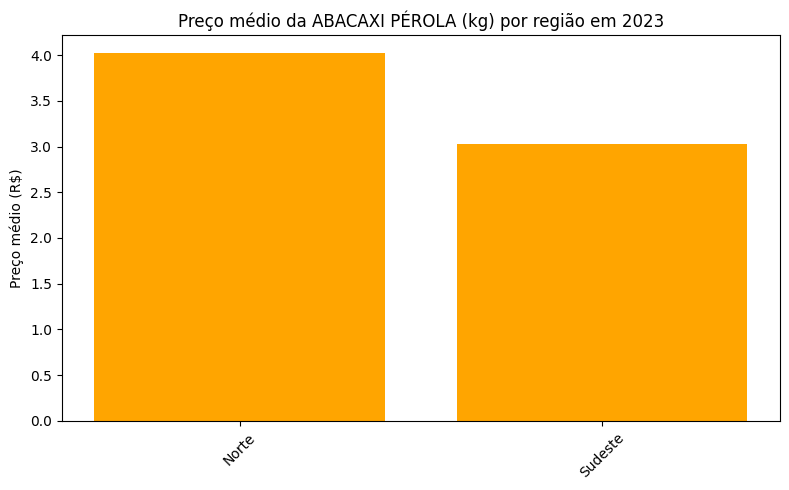

In [17]:
# Filtrar o produto específico
abacaxi = df_novo[(df_novo['produto_nome'] == 'ABACAXI PÉROLA') & (df_novo['unidade'] == 'kg')]

# Calcular a média anual por região
media_regiao = abacaxi.groupby('regiao')['preco_medio'].mean().reset_index()
media_regiao = media_regiao.sort_values('preco_medio', ascending=False)

# Exibir
print("Preço médio anual da ABACAXI PÉROLA (kg) por região:")
print(media_regiao)

# Região com maior preço
maior = media_regiao.iloc[0]
print(f"\nRegião com maior preço médio: {maior['regiao']} (R${maior['preco_medio']:.2f})")

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(media_regiao['regiao'], media_regiao['preco_medio'], color='orange')
plt.ylabel('Preço médio (R$)')
plt.title('Preço médio da ABACAXI PÉROLA (kg) por região em 2023')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Análise 3: Existe sazonalidade no preço do ABACATE (kg) ao longo dos meses?

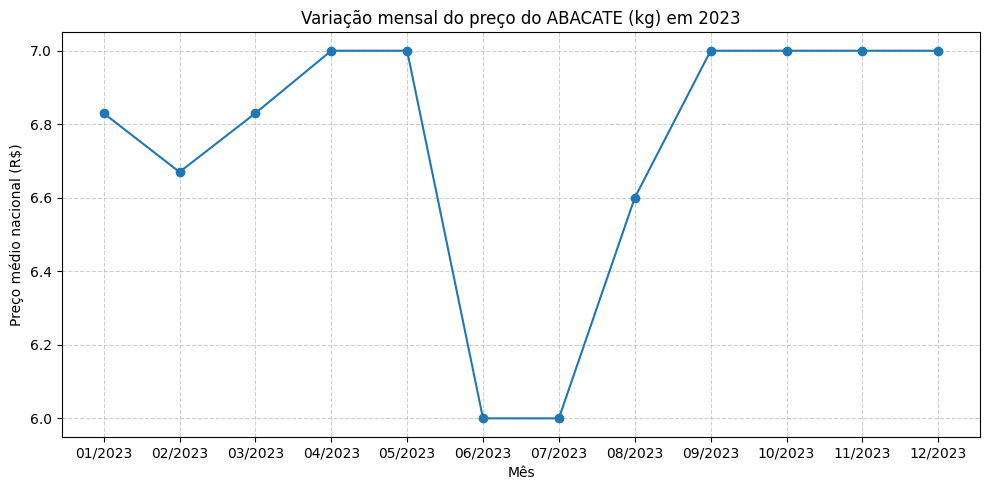

Preço médio por mês:
    mes_ano  preco_medio  mes_num
0   01/2023         6.83        1
1   02/2023         6.67        2
2   03/2023         6.83        3
3   04/2023         7.00        4
4   05/2023         7.00        5
5   06/2023         6.00        6
6   07/2023         6.00        7
7   08/2023         6.60        8
8   09/2023         7.00        9
9   10/2023         7.00       10
10  11/2023         7.00       11
11  12/2023         7.00       12

Mês com maior preço: 04/2023 (R$7.00)
Mês com menor preço: 06/2023 (R$6.00)


In [18]:
# Filtrar abacate em kg
abacate = df_novo[(df_novo['produto_nome'] == 'ABACATE') & (df_novo['unidade'] == 'kg')]

# Calcular a média nacional por mês (considerando todas as UFs e níveis)
media_mensal = abacate.groupby('mes_ano')['preco_medio'].mean().reset_index()

# Ordenar cronologicamente (já que mes_ano está como string, converter para data)
media_mensal['mes_num'] = pd.to_datetime(media_mensal['mes_ano'], format='%m/%Y').dt.month
media_mensal = media_mensal.sort_values('mes_num')

# Gráfico de linha
plt.figure(figsize=(10,5))
plt.plot(media_mensal['mes_ano'], media_mensal['preco_medio'], marker='o', linestyle='-')
plt.ylabel('Preço médio nacional (R$)')
plt.xlabel('Mês')
plt.title('Variação mensal do preço do ABACATE (kg) em 2023')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Estatísticas
print("Preço médio por mês:")
print(media_mensal)
print(f"\nMês com maior preço: {media_mensal.loc[media_mensal['preco_medio'].idxmax(), 'mes_ano']} (R${media_mensal['preco_medio'].max():.2f})")
print(f"Mês com menor preço: {media_mensal.loc[media_mensal['preco_medio'].idxmin(), 'mes_ano']} (R${media_mensal['preco_medio'].min():.2f})")

In [23]:
abacate_kg = df[(df['produto_nome'] == 'ABACATE') & (df['unidade'] == 'kg')]

print(f"Total de linhas para Abacate (kg): {len(abacate_kg)}")
print(f"Estados (UF) presentes: {abacate_kg['U.F.'].unique()}")
print(f"Quantidade de UFs distintas: {abacate_kg['U.F.'].nunique()}")

Total de linhas para Abacate (kg): 1
Estados (UF) presentes: ['RR']
Quantidade de UFs distintas: 1


Limitação importante: a base contém apenas um registro de Abacate (kg) no ano inteiro, referente a Roraima (Atacado). A conclusão acima vale para esse estado especificamente, não para o Brasil — não há dados suficientes para generalizar.

## Análise 4: O preço do arroz no atacado é diferente do varejo?

Preço médio do arroz (kg) por nível de comercialização:
  Nível de Comercialização  preco_medio
0                  ATACADO     4.765000
1                   VAREJO     5.198041


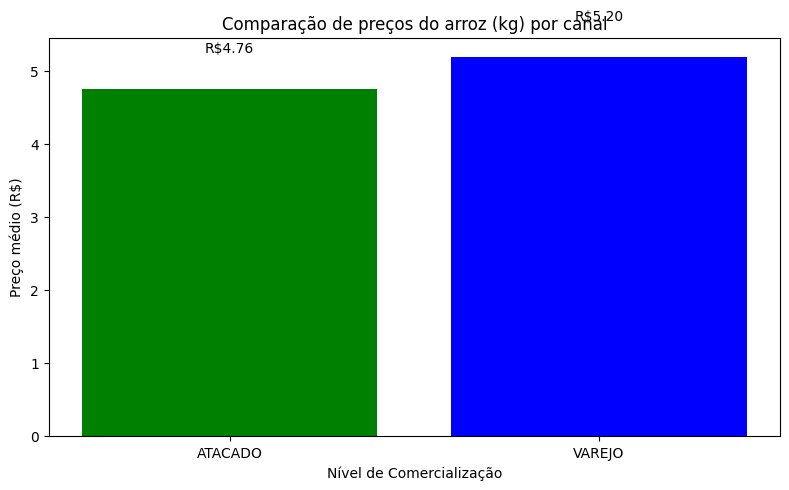


O varejo é 9.09% mais caro que o atacado.


In [19]:
# Filtrar produtos que contenham "ARROZ" (exemplo: ARROZ LONGO FINO...) e unidade 'kg'
arroz = df_novo[(df_novo['produto_nome'].str.contains('ARROZ', case=False)) & (df_novo['unidade'] == 'kg')]

# Calcular média por nível de comercialização
media_nivel = arroz.groupby('Nível de Comercialização')['preco_medio'].mean().reset_index()

print("Preço médio do arroz (kg) por nível de comercialização:")
print(media_nivel)

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(media_nivel['Nível de Comercialização'], media_nivel['preco_medio'], color=['green', 'blue', 'red'])
plt.ylabel('Preço médio (R$)')
plt.xlabel('Nível de Comercialização')
plt.title('Comparação de preços do arroz (kg) por canal')
for i, row in media_nivel.iterrows():
    plt.text(row['Nível de Comercialização'], row['preco_medio']+0.5, f'R${row["preco_medio"]:.2f}', ha='center')
plt.tight_layout()
plt.show()

# Comparação direta (atacado vs varejo)
if 'ATACADO' in media_nivel['Nível de Comercialização'].values and 'VAREJO' in media_nivel['Nível de Comercialização'].values:
    preco_atacado = media_nivel[media_nivel['Nível de Comercialização'] == 'ATACADO']['preco_medio'].values[0]
    preco_varejo = media_nivel[media_nivel['Nível de Comercialização'] == 'VAREJO']['preco_medio'].values[0]
    diferenca_pct = (preco_varejo - preco_atacado) / preco_atacado * 100
    print(f"\nO varejo é {diferenca_pct:.2f}% mais caro que o atacado.")
    

## Análise 5: Quais foram os 5 meses com maior preço médio geral (todos os produtos e UFs)?

5 meses com maior preço médio geral (todos os produtos):
   mes_ano  preco_medio
2  03/2023   101.696596
1  02/2023   101.015315
0  01/2023   100.773845
3  04/2023   100.485043
4  05/2023    98.730324


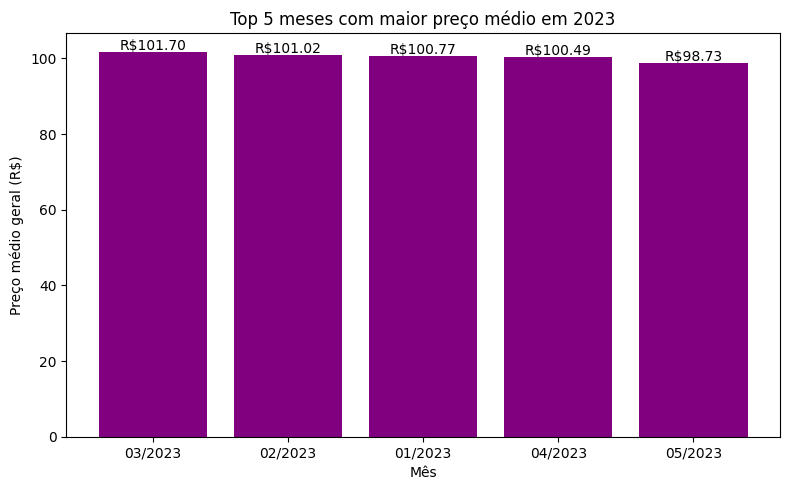

In [20]:
# Média geral simples por mês (sem ponderação por volume de vendas – apenas a média dos preços registrados)
media_geral_mes = df_novo.groupby('mes_ano')['preco_medio'].mean().reset_index()

# Ordenar e pegar os 5 maiores
top5_meses = media_geral_mes.nlargest(5, 'preco_medio')

print("5 meses com maior preço médio geral (todos os produtos):")
print(top5_meses)

# Gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(top5_meses['mes_ano'], top5_meses['preco_medio'], color='purple')
plt.ylabel('Preço médio geral (R$)')
plt.xlabel('Mês')
plt.title('Top 5 meses com maior preço médio em 2023')
for i, row in top5_meses.iterrows():
    plt.text(row['mes_ano'], row['preco_medio']+0.5, f'R${row["preco_medio"]:.2f}', ha='center')
plt.tight_layout()
plt.show()